In [3]:
import polars as pl 
import plotly.express as px
from pathlib import Path
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [4]:
project_dir = Path("/home/kali/supreme-adventure/data")
output_dir = Path("/home/kali/supreme-adventure/output")

print("Project exists :", project_dir.exists())
print("Output exists  :", output_dir.exists())

if project_dir.exists():
    print("\nIsi project dir:")
    for p in sorted(project_dir.iterdir()):
        print("-", p.name)

Project exists : True
Output exists  : True

Isi project dir:
- Bawang Merah.csv
- Bawang Putih Bonggol.csv
- Beras Medium.csv
- Beras Premium.csv
- Cabai Merah Keriting.csv
- Cabai Rawit Merah.csv
- Daging Ayam Ras.csv
- Daging Sapi Murni.csv
- Gula Konsumsi.csv
- Minyak Goreng Curah.csv
- Minyak Goreng Kemasan Sederhana.csv
- Telur Ayam Ras.csv
- Tepung Terigu (Curah).csv


In [5]:
KOMODITAS = {
    'bawang_merah': 'Bawang Merah.csv',
    'beras_medium': 'Beras Medium.csv',
    'beras_premium' : 'Beras Premium.csv',
    'minyak_curah': 'Minyak Goreng Curah.csv',
    'telur_ayam': 'Telur Ayam Ras.csv',
    'gula': 'Gula Konsumsi.csv',
    'Bawang_Putih_Bonggol' : 'Bawang Putih Bonggol.csv',
    'Cabai_Merah_Keriting' : 'Cabai Merah Keriting.csv',
    'Cabai_Rawit_Merah' : 'Cabai Rawit Merah.csv',
    'Daging_Ayam_Ras' : 'Daging Ayam Ras.csv',
    'Daging_Sapi_Murni': 'Daging Sapi Murni.csv',
    'Minyak_Goreng_Kemasan_Sederhana' : 'Minyak Goreng Kemasan Sederhana.csv',
    'Tepung_Terigu_Curah' : 'Tepung Terigu (Curah).csv'
}

In [6]:
data = {}

for key, filename in KOMODITAS.items():
    file_path = project_dir / filename
    data[key] = pl.read_csv(file_path)
    print(f"✓ {key}: {data[key].shape}")

✓ bawang_merah: (1004, 35)
✓ beras_medium: (1004, 35)
✓ beras_premium: (1004, 35)
✓ minyak_curah: (1004, 35)
✓ telur_ayam: (1004, 35)
✓ gula: (1004, 35)
✓ Bawang_Putih_Bonggol: (1004, 35)
✓ Cabai_Merah_Keriting: (1004, 35)
✓ Cabai_Rawit_Merah: (1004, 35)
✓ Daging_Ayam_Ras: (1004, 35)
✓ Daging_Sapi_Murni: (1004, 35)
✓ Minyak_Goreng_Kemasan_Sederhana: (1004, 35)
✓ Tepung_Terigu_Curah: (1004, 35)


In [7]:
print("Shape dari semua dataset: ")
i: int = 1;
for key,df in data.items(): 
    print(f"{i}. {key:20}: {df.shape}")
    i = i + 1

Shape dari semua dataset: 
1. bawang_merah        : (1004, 35)
2. beras_medium        : (1004, 35)
3. beras_premium       : (1004, 35)
4. minyak_curah        : (1004, 35)
5. telur_ayam          : (1004, 35)
6. gula                : (1004, 35)
7. Bawang_Putih_Bonggol: (1004, 35)
8. Cabai_Merah_Keriting: (1004, 35)
9. Cabai_Rawit_Merah   : (1004, 35)
10. Daging_Ayam_Ras     : (1004, 35)
11. Daging_Sapi_Murni   : (1004, 35)
12. Minyak_Goreng_Kemasan_Sederhana: (1004, 35)
13. Tepung_Terigu_Curah : (1004, 35)


In [8]:
print("Statistik Deskriptif dari semua dataset")
for key,df in data.items():
    print(f"{key:20}: {df.describe()}")

Statistik Deskriptif dari semua dataset
bawang_merah        : shape: (9, 36)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ Date      ┆ Aceh      ┆ Bali      ┆ … ┆ Sulawesi  ┆ Sumatera  ┆ Sumatera  ┆ Sumatera │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ Utara     ┆ Barat     ┆ Selatan   ┆ Utara    │
│ str       ┆ str       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 1004      ┆ 967.0     ┆ 968.0     ┆ … ┆ 970.0     ┆ 969.0     ┆ 966.0     ┆ 968.0    │
│ null_coun ┆ 0         ┆ 37.0      ┆ 36.0      ┆ … ┆ 34.0      ┆ 35.0      ┆ 38.0      ┆ 36.0     │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ 

In [9]:
i: int = 1;
for key,df in data.items():
    print(f"{i}.{key:20}: {df.schema} \n")
    i = i + 1

1.bawang_merah        : Schema({'Date': String, 'Aceh': Float64, 'Bali': Float64, 'Banten': Float64, 'Bengkulu': Float64, 'DI Yogyakarta': Float64, 'DKI Jakarta': Float64, 'Gorontalo': Float64, 'Jambi': Float64, 'Jawa Barat': Float64, 'Jawa Tengah': Float64, 'Jawa Timur': Float64, 'Kalimantan Barat': Float64, 'Kalimantan Selatan': Float64, 'Kalimantan Tengah': Float64, 'Kalimantan Timur': Float64, 'Kalimantan Utara': Float64, 'Kepulauan Bangka Belitung': Float64, 'Kepulauan Riau': Float64, 'Lampung': Float64, 'Maluku Utara': Float64, 'Maluku': Float64, 'Nusa Tenggara Barat': Float64, 'Nusa Tenggara Timur': Float64, 'Papua Barat': Float64, 'Papua': Float64, 'Riau': Float64, 'Sulawesi Barat': Float64, 'Sulawesi Selatan': Float64, 'Sulawesi Tengah': Float64, 'Sulawesi Tenggara': Float64, 'Sulawesi Utara': Float64, 'Sumatera Barat': Float64, 'Sumatera Selatan': Float64, 'Sumatera Utara': Float64}) 

2.beras_medium        : Schema({'Date': String, 'Aceh': Float64, 'Bali': Float64, 'Banten':

In [10]:
i: int = 1
print(f"persentase missing")
for key,df in data.items():
    total_miss = df.select(pl.all().null_count().sum().item())
    total_data = df.height * df.width
    percent = (total_miss / total_data) * 100
    print(f"{i}.{key:20}: {percent}")
    i = i + 1

persentase missing
1.bawang_merah        : shape: (1, 35)
┌──────┬──────────┬──────────┬──────────┬───┬─────────────┬─────────────┬─────────────┬────────────┐
│ Date ┆ Aceh     ┆ Bali     ┆ Banten   ┆ … ┆ Sulawesi    ┆ Sumatera    ┆ Sumatera    ┆ Sumatera   │
│ ---  ┆ ---      ┆ ---      ┆ ---      ┆   ┆ Utara       ┆ Barat       ┆ Selatan     ┆ Utara      │
│ f64  ┆ f64      ┆ f64      ┆ f64      ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---        │
│      ┆          ┆          ┆          ┆   ┆ f64         ┆ f64         ┆ f64         ┆ f64        │
╞══════╪══════════╪══════════╪══════════╪═══╪═════════════╪═════════════╪═════════════╪════════════╡
│ 0.0  ┆ 0.105293 ┆ 0.102447 ┆ 0.105293 ┆ … ┆ 0.096756    ┆ 0.099602    ┆ 0.108139    ┆ 0.102447   │
└──────┴──────────┴──────────┴──────────┴───┴─────────────┴─────────────┴─────────────┴────────────┘
2.beras_medium        : shape: (1, 35)
┌──────┬──────────┬──────────┬──────────┬───┬─────────────┬─────────────┬─────────────┬────────

In [11]:
i: int = 0
for key,df in data.items():
    total_col: int = df.height * df.width
    missing = df.select(
        pl.sum_horizontal(pl.all().null_count())
    ).item()
    persentase: float = (missing / total_col) * 100
    print(f"{key:20s} : {missing} missing ({persentase:.2f}%)")
    i = i + 1

bawang_merah         : 1241 missing (3.53%)
beras_medium         : 1241 missing (3.53%)
beras_premium        : 1241 missing (3.53%)
minyak_curah         : 5437 missing (15.47%)
telur_ayam           : 1241 missing (3.53%)
gula                 : 1241 missing (3.53%)
Bawang_Putih_Bonggol : 1241 missing (3.53%)
Cabai_Merah_Keriting : 1244 missing (3.54%)
Cabai_Rawit_Merah    : 2035 missing (5.79%)
Daging_Ayam_Ras      : 1241 missing (3.53%)
Daging_Sapi_Murni    : 1245 missing (3.54%)
Minyak_Goreng_Kemasan_Sederhana : 1289 missing (3.67%)
Tepung_Terigu_Curah  : 1242 missing (3.53%)


# Analisis Missing
Terlihat rata missing value ada di angka 3% dan hanya minyak curah yg memiliki persentase 15%,dikarenakan yang akan di cluster adalah provinsi jadi selanjutnya akan di cek jumlah missing per provinsi untuk diputuskan apakah akan di drop

In [12]:
for key, df in data.items():
    print(f"\n📊 {key.upper()}")
    # =========================
    # 1. Missing per kolom
    # =========================
    missing_per_col = (
        df.select(pl.all().null_count())
        .transpose(include_header=True)
        .rename({"column": "provinsi", "column_0": "missing"})
        .filter(pl.col("missing") > 0)
        .sort("missing", descending=True)
    )

    if missing_per_col.height > 0:
        print("Provinsi dengan missing value:")

        top10 = missing_per_col.head(10)

        for row in top10.iter_rows(named=True):
            prov = row["provinsi"]
            count = row["missing"]
            pct = (count / df.height) * 100

            print(f"  {prov:25s} : {count:4d} missing ({pct:5.2f}%)")
    else:
        print("  ✓ No missing values")

    # =========================
    # 2. Missing per baris
    # =========================
    missing_per_row = df.select(
        pl.sum_horizontal(pl.all().is_null()).alias("missing")
    )

    rows_with_missing = missing_per_row.filter(pl.col("missing") > 0).height

    print(
        f"\nBaris dengan missing: {rows_with_missing} dari {df.height} "
        f"({(rows_with_missing/df.height)*100:.2f}%)"
    )


📊 BAWANG_MERAH
Provinsi dengan missing value:
  Kalimantan Timur          :   39 missing ( 3.88%)
  Kalimantan Utara          :   39 missing ( 3.88%)
  Kepulauan Riau            :   39 missing ( 3.88%)
  Papua Barat               :   39 missing ( 3.88%)
  Sulawesi Barat            :   39 missing ( 3.88%)
  Jambi                     :   38 missing ( 3.78%)
  Kepulauan Bangka Belitung :   38 missing ( 3.78%)
  Sumatera Selatan          :   38 missing ( 3.78%)
  Aceh                      :   37 missing ( 3.69%)
  Banten                    :   37 missing ( 3.69%)

Baris dengan missing: 46 dari 1004 (4.58%)

📊 BERAS_MEDIUM
Provinsi dengan missing value:
  Kalimantan Timur          :   39 missing ( 3.88%)
  Kalimantan Utara          :   39 missing ( 3.88%)
  Kepulauan Riau            :   39 missing ( 3.88%)
  Papua Barat               :   39 missing ( 3.88%)
  Sulawesi Barat            :   39 missing ( 3.88%)
  Jambi                     :   38 missing ( 3.78%)
  Kepulauan Bangka Belitung : 

# Analisis

Karena missing yang cukup signifikan pada dataset cabai rawit merah sebesar 80% dan minya curah sekitar 40%,maka kita harus drop untuk dataset tersebut.


## Note
Tersisa 11 Dataset

# Feature

Cari tau Tipe Missing pada 11 dataset tersebut,apakah MCAR,MAR,atau MNAR

# Drop 2 dataset cabai rawit merah dan minyak curah

In [13]:
del data["minyak_curah"]
del data["Cabai_Rawit_Merah"]

In [14]:
i: int = 1
for key,df in data.items():
    print(f"{i}.{key:20}: {df.height} kolom x {df.width} baris ")
    i = i + 1

1.bawang_merah        : 1004 kolom x 35 baris 
2.beras_medium        : 1004 kolom x 35 baris 
3.beras_premium       : 1004 kolom x 35 baris 
4.telur_ayam          : 1004 kolom x 35 baris 
5.gula                : 1004 kolom x 35 baris 
6.Bawang_Putih_Bonggol: 1004 kolom x 35 baris 
7.Cabai_Merah_Keriting: 1004 kolom x 35 baris 
8.Daging_Ayam_Ras     : 1004 kolom x 35 baris 
9.Daging_Sapi_Murni   : 1004 kolom x 35 baris 
10.Minyak_Goreng_Kemasan_Sederhana: 1004 kolom x 35 baris 
11.Tepung_Terigu_Curah : 1004 kolom x 35 baris 


In [15]:
missing_matrix = next(iter(data.values())).select("Date")

for key, df in data.items():
    miss = (
        df.drop("Date")
        .select(pl.any_horizontal(pl.all().is_null()).cast(pl.Int8))
        .to_series()
    )

    missing_matrix = missing_matrix.with_columns(
        miss.alias(key)
    )
    

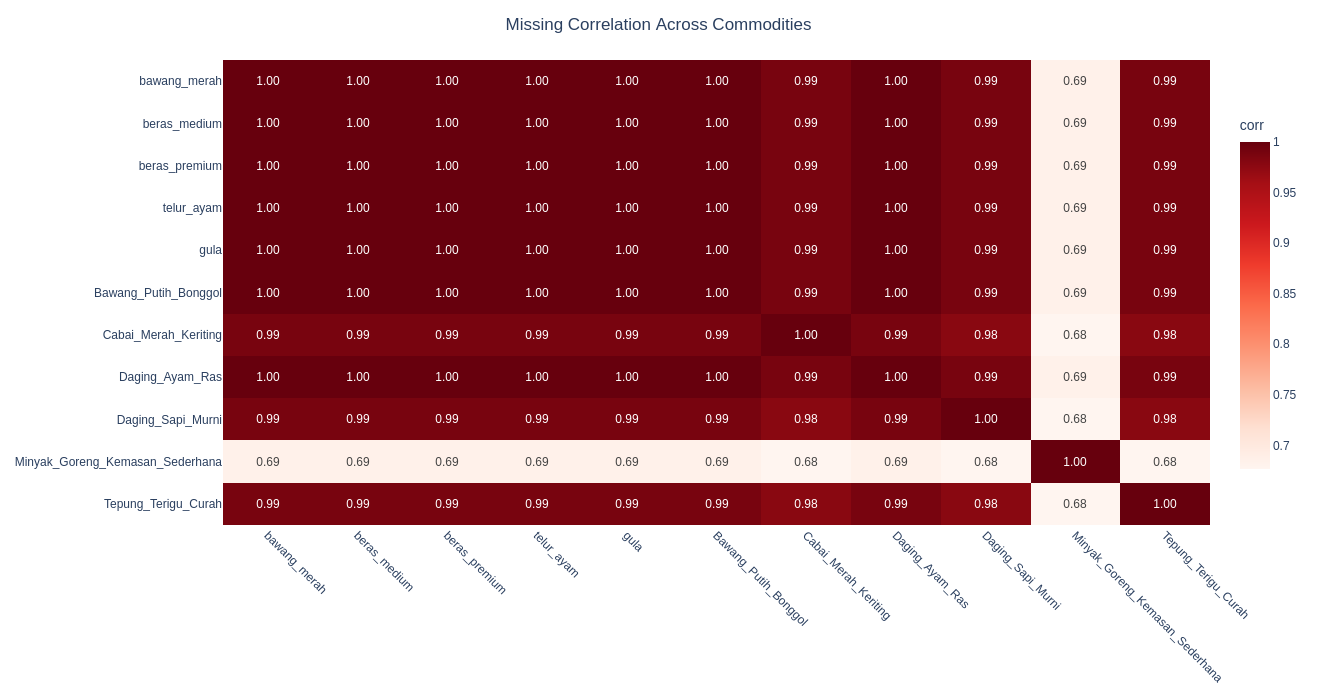

In [16]:
missing_corr = (
    missing_matrix
    .drop("Date")
    .to_pandas()
    .corr()
)
fig = px.imshow(
    missing_corr,
    text_auto=".2f",
    color_continuous_scale="Reds",
    aspect="auto"
)

fig.update_layout(
    title="Missing Correlation Across Commodities",
    title_x=0.5,
    width=900,
    height=700,
    font=dict(size=12),
    coloraxis_colorbar=dict(
        title="corr",
        len=0.8
    )
)

fig.update_xaxes(
    tickangle=45,
    side="bottom"
)

fig.update_yaxes(
    autorange="reversed"
)

fig.show()

In [17]:
print(missing_matrix.head(20))

shape: (20, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Date      ┆ bawang_me ┆ beras_med ┆ beras_pre ┆ … ┆ Daging_Ay ┆ Daging_Sa ┆ Minyak_Go ┆ Tepung_T │
│ ---       ┆ rah       ┆ ium       ┆ mium      ┆   ┆ am_Ras    ┆ pi_Murni  ┆ reng_Kema ┆ erigu_Cu │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ san_Seder ┆ rah      │
│           ┆ i8        ┆ i8        ┆ i8        ┆   ┆ i8        ┆ i8        ┆ han…      ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ ---       ┆ i8       │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ i8        ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2022-01-0 ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0         ┆ 0         ┆ 0         ┆ 0        │
│ 1         ┆           ┆           ┆           ┆   ┆           ┆          

In [18]:
missing_matrix = missing_matrix.with_columns(
    pl.sum_horizontal(pl.exclude("Date")).alias("total")
)

missing_matrix.sort("total", descending=True).head(10)

Date,bawang_merah,beras_medium,beras_premium,telur_ayam,gula,Bawang_Putih_Bonggol,Cabai_Merah_Keriting,Daging_Ayam_Ras,Daging_Sapi_Murni,Minyak_Goreng_Kemasan_Sederhana,Tepung_Terigu_Curah,total
str,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
"""2022-03-22""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-05-03""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-10""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-11""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-12""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-13""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-14""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-15""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-16""",1,1,1,1,1,1,1,1,1,1,1,11


In [19]:
missing_matrix.select(pl.col("total").value_counts())

total
struct[2]
"{1,50}"
"{0,908}"
"{11,46}"


In [20]:
# ======================
# build missing matrix
# ======================
missing_matrix = next(iter(data.values())).select("Date")

for key, df in data.items():
    miss = (
        df.drop("Date")
        .select(pl.any_horizontal(pl.all().is_null()).cast(pl.Int8))
        .to_series()
    )

    missing_matrix = missing_matrix.with_columns(
        miss.alias(key)
    )

# ======================
# overlap calculation
# ======================
X = missing_matrix.drop("Date").to_numpy()

overlap = X.T @ X

overlap_df = pl.DataFrame(
    overlap,
    schema=missing_matrix.drop("Date").columns
)


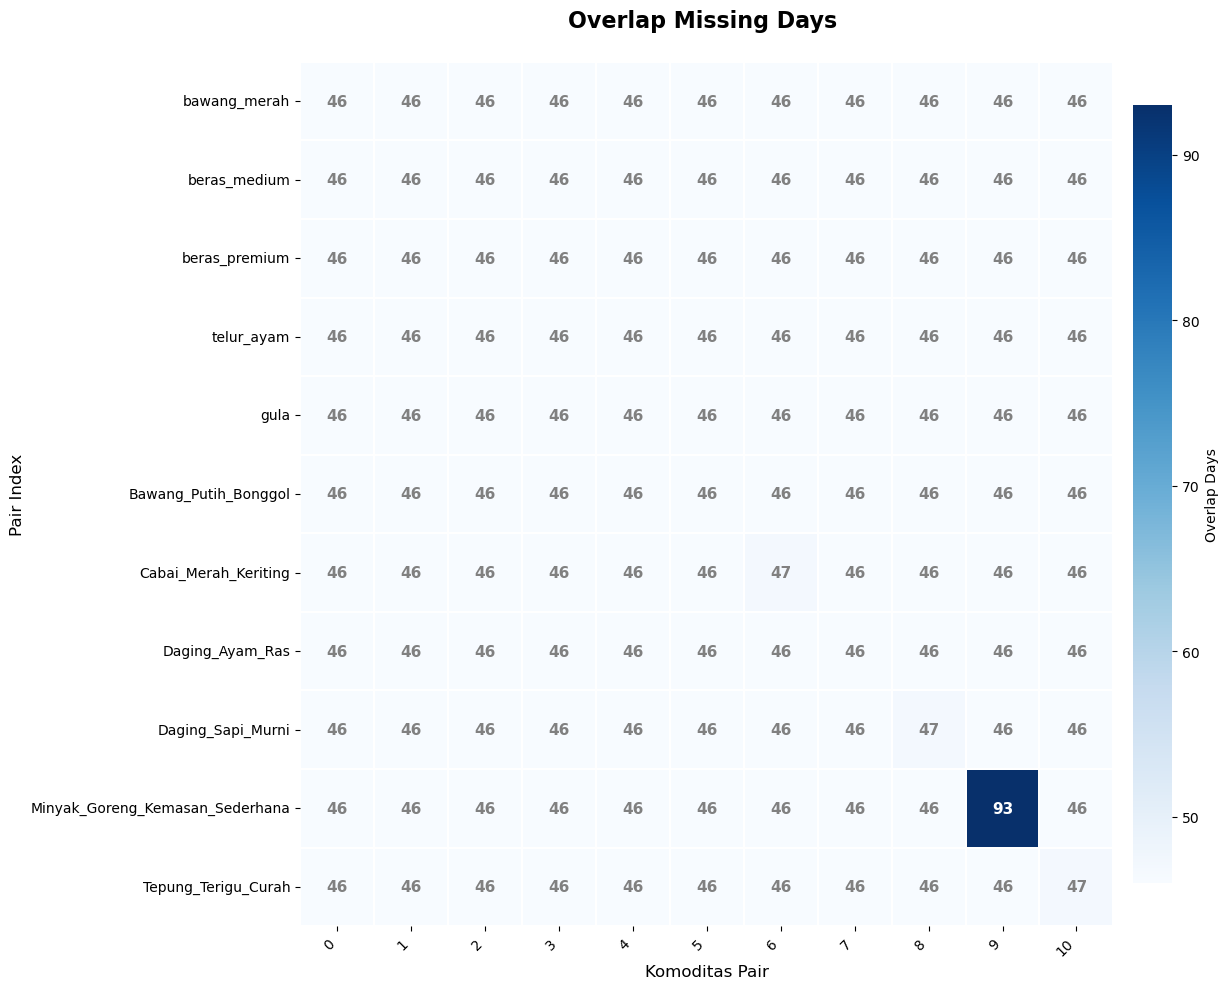

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

data_numeric = missing_matrix.to_pandas().select_dtypes(include='number')
overlap = data_numeric.T @ data_numeric.values

plt.figure(figsize=(13, 10))
sns.heatmap(
    overlap,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1.2,      # ← Grid lebih tebal
    linecolor='white',
    cbar_kws={
        'label': 'Overlap Days', 
        'shrink': 0.9,     # ← Colorbar lebih lebar
        'pad': 0.02
    },
    annot_kws={'size': 11, 'fontweight': 'bold', 'color': 'gray'}
)

# Highlight outlier
for text in plt.gca().texts:
    if float(text.get_text()) > 80:
        text.set_color('white')

plt.title("Overlap Missing Days ", 
          fontsize=16, fontweight='bold', pad=25)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Komoditas Pair', fontsize=12)
plt.ylabel('Pair Index', fontsize=12)
plt.tight_layout()
plt.show()

# Analis
Pada visualisasi korelasi missing value antar komoditas dengan heatmap terlihat bahwa 10 dari 11 komoditas memiliki missing value yang identik yang dimana hal itu cukup untuk menarik kesimpulan bahwa tipe missing valuenya adalah MNAR atau dengan kata lain sistematis,sementara itu komoditas minyak goreng hanya memiliki korelasi sekitar $ 68\\% $ ,ini mengartikan bahwa missing value pada komoditas minyak goreng berbeda dengan 10 komoditas lainnya sekitar $ 32 \\%$  bersifat unik karena tidak muncul pada 10 komoditas lain,maka pilihannya adalah drop komoditas minyak goreng karena ada kemunkinan dimana kemunkinan besar komoditas minyak goreng adalah outlier

Visualisi Heatmap kedua bertujuan untuk menghitung jumlah hari yang sama ketika dua komoditas mengalami missing,hasil menunjukkan berbeda dengan komoditas lain yg mayoritas 46 - 47 hari minyak goreng malah missing sebanyak 93 hari artinya setengah missing di komoditas ini tidak muncul di komoditas lain, hal ini menegaskan bahwa komoditas minyak goreng adalah anomali atau outiers

# Keputusan
- [x] Drop dataset minyak_goreng sederhana
# Feature
- [x] Cari apakah ada rentang waktu sama,10 dataset tersisa memiliki rentang waktu missing yang sama
- [x] apakah interpolasi bisa dilakukan pada dataset tersisa,dan interpolasi apa(linear,atau polynomial)? 

In [22]:
del data["Minyak_Goreng_Kemasan_Sederhana"]

In [23]:
print("DATASET TERSISA")
i: int = 1
for key,df in data.items():
    print(f"{i}.{key:20}: {df.height} baris x {df.width} kolom")
    i = i + 1

DATASET TERSISA
1.bawang_merah        : 1004 baris x 35 kolom
2.beras_medium        : 1004 baris x 35 kolom
3.beras_premium       : 1004 baris x 35 kolom
4.telur_ayam          : 1004 baris x 35 kolom
5.gula                : 1004 baris x 35 kolom
6.Bawang_Putih_Bonggol: 1004 baris x 35 kolom
7.Cabai_Merah_Keriting: 1004 baris x 35 kolom
8.Daging_Ayam_Ras     : 1004 baris x 35 kolom
9.Daging_Sapi_Murni   : 1004 baris x 35 kolom
10.Tepung_Terigu_Curah : 1004 baris x 35 kolom


In [24]:
missing_matrix = next(iter(data.values())).select("Date")

for key, df in data.items():
    miss = (
        df.drop("Date")
        .select(pl.any_horizontal(pl.all().is_null()).cast(pl.Int8))
        .to_series()
    )

    missing_matrix = missing_matrix.with_columns(
        miss.alias(key)
    )

blackout_days = missing_matrix.filter(
    pl.all_horizontal(pl.exclude("Date") == 1)
)

print("Jumlah blackout day:", blackout_days.height)
print(f"{blackout_days.select("Date").sort("Date")}")

Jumlah blackout day: 46
shape: (46, 1)
┌────────────┐
│ Date       │
│ ---        │
│ str        │
╞════════════╡
│ 2022-03-22 │
│ 2022-05-03 │
│ 2022-06-10 │
│ 2022-06-11 │
│ 2022-06-12 │
│ …          │
│ 2024-03-11 │
│ 2024-04-10 │
│ 2024-04-11 │
│ 2024-06-17 │
│ 2024-06-18 │
└────────────┘


In [25]:
blackout = (
    blackout_days
    .with_columns(
        pl.col("Date").str.to_date()
    )
    .select("Date")
    .sort("Date")
    .with_columns(
        pl.col("Date").diff().dt.total_days().alias("gap")
    )
    .with_columns(
        (pl.col("gap").fill_null(1) != 1).cum_sum().alias("group")
    )
    .group_by("group")
    .agg([
        pl.col("Date").min().alias("start"),
        pl.col("Date").max().alias("end"),
        pl.len().alias("length")
    ])
    .drop("group")
)

print(blackout)

shape: (10, 3)
┌────────────┬────────────┬────────┐
│ start      ┆ end        ┆ length │
│ ---        ┆ ---        ┆ ---    │
│ date       ┆ date       ┆ u32    │
╞════════════╪════════════╪════════╡
│ 2024-04-10 ┆ 2024-04-11 ┆ 2      │
│ 2022-03-22 ┆ 2022-03-22 ┆ 1      │
│ 2024-06-17 ┆ 2024-06-18 ┆ 2      │
│ 2022-06-10 ┆ 2022-07-14 ┆ 35     │
│ 2023-09-20 ┆ 2023-09-20 ┆ 1      │
│ 2022-08-03 ┆ 2022-08-03 ┆ 1      │
│ 2022-05-03 ┆ 2022-05-03 ┆ 1      │
│ 2024-03-11 ┆ 2024-03-11 ┆ 1      │
│ 2023-04-22 ┆ 2023-04-22 ┆ 1      │
│ 2023-01-09 ┆ 2023-01-09 ┆ 1      │
└────────────┴────────────┴────────┘


# Analisis

Dari 46 missing days,terdapat rentang pendek(1 - 2 hari) dan rentang panjang(35 hari),strateginya adalah melakukan interpolasi pada rentang pendek lebih tepatnya Interpolasi Linear(mencari fungsi $y = f(x)$ yang melewati semua titik $x$).dan untuk rentang panjang dibiarkan null saja

# Feature

- [x] lakukan interpolasi linear pada rentang pendek(1 - 2 hari)

In [26]:
import polars as pl

def interpolate_short(df, max_gap=2):
    # Pastikan data diurutkan
    df = df.sort("Date")
    
    exprs = [] # Tampung semua operasi kolom di list ini
    
    for c in df.columns:
        if c == "Date":
            continue

        # 1. Mask null
        is_null = pl.col(c).is_null()

        # 2. Hitung group id (tambahkan fill_null untuk baris pertama)
        grp = (is_null != is_null.shift()).fill_null(False).cum_sum()

        # 3. Panjang run null (Perbaiki urutan .sum() dan .over())
        run_len = (
            pl.when(is_null)
            .then(1)
            .otherwise(0)
            .sum()
            .over(grp)
        )

        # 4. Interpolasi kandidat (hitung semua)
        interp = pl.col(c).interpolate()

        # 5. Buat ekspresi: isi dengan interpolasi HANYA jika null dan gap <= max_gap
        expr = (
            pl.when(is_null & (run_len <= max_gap))
            .then(interp)
            .otherwise(pl.col(c))
            .alias(c) # Pastikan nama kolom tidak berubah
        )
        
        exprs.append(expr)

    # Eksekusi semuanya secara paralel dalam 1 panggilan (Sangat Cepat)
    out = df.with_columns(exprs)
    
    return out

# Cara panggilnya tetap sama:
cleaned = {k: interpolate_short(df, max_gap=2) for k, df in data.items()}

In [27]:
summary_data = []

for key, df in cleaned.items():
    # 1. Hitung jumlah null untuk semua kolom (hasilnya 1 baris)
    null_counts = df.select(pl.all().null_count())
    
    # 2. Hitung total seluruh null di dataset ini
    total_nulls = null_counts.select(pl.sum_horizontal(pl.all())).item()
    
    # 3. Cari tahu kolom spesifik mana yang masih memiliki null
    cols_with_nulls = [
        col for col in null_counts.columns 
        if null_counts.get_column(col)[0] > 0
    ]
    
    # 4. Tentukan Status
    if total_nulls == 0:
        status = "✅ Berhasil"
    else:
        status = "❌ Gagal (Gap terlalu besar)"
        
    # 5. Simpan ke dalam list dictionary
    summary_data.append({
        "Dataset": key,
        "Sisa Null": total_nulls,
        "Kolom Bermasalah": ", ".join(cols_with_nulls) if cols_with_nulls else "-",
        "Status": status
    })

# 6. Ubah menjadi Polars DataFrame agar di-print sebagai tabel yang rapi
summary_df = pl.DataFrame(summary_data)

print("=== RINGKASAN HASIL INTERPOLASI ===")
print(summary_df)

=== RINGKASAN HASIL INTERPOLASI ===
shape: (10, 4)
┌──────────────────────┬───────────┬────────────────────────────────┬──────────────────────────────┐
│ Dataset              ┆ Sisa Null ┆ Kolom Bermasalah               ┆ Status                       │
│ ---                  ┆ ---       ┆ ---                            ┆ ---                          │
│ str                  ┆ i64       ┆ str                            ┆ str                          │
╞══════════════════════╪═══════════╪════════════════════════════════╪══════════════════════════════╡
│ bawang_merah         ┆ 1160      ┆ Aceh, Bali, Banten, Bengkulu,  ┆ ❌ Gagal (Gap terlalu besar) │
│                      ┆           ┆ …                              ┆                              │
│ beras_medium         ┆ 1160      ┆ Aceh, Bali, Banten, Bengkulu,  ┆ ❌ Gagal (Gap terlalu besar) │
│                      ┆           ┆ …                              ┆                              │
│ beras_premium        ┆ 1160      ┆ Aceh,

In [28]:
# 1. Ambil kolom Date dari DataFrame pertama sebagai base
base_df = next(iter(cleaned.values())).select("Date")

# 2. Tampung hasil pengecekan missing value di list ini
miss_series_list = []

for key, df in cleaned.items():
    # Cek apakah ada nilai null di baris tersebut (selain kolom Date)
    # Hasilnya berupa Boolean (True jika ada null, False jika aman)
    miss_series = (
        df.select(pl.any_horizontal(pl.exclude("Date").is_null()))
        .to_series()
        .alias(key)
    )
    miss_series_list.append(miss_series)

# 3. Gabungkan semua kolom missing ke matriks sekaligus (Sangat Cepat)
missing_matrix = base_df.with_columns(miss_series_list)

# 4. Filter baris di mana SEMUA dataframe mengalami missing (True)
blackout = (
    missing_matrix
    .filter(pl.all_horizontal(pl.exclude("Date")))
    .select("Date") # Hanya tampilkan tanggal agar output bersih
)

print("=== DAFTAR TANGGAL BLACKOUT ===")
if blackout.height > 0:
    print(blackout)
    print(f"Total: {blackout.height} hari blackout.")
else:
    print("Tidak ada tanggal blackout (selalu ada data di minimal satu dataframe).")

=== DAFTAR TANGGAL BLACKOUT ===
shape: (35, 1)
┌────────────┐
│ Date       │
│ ---        │
│ str        │
╞════════════╡
│ 2022-06-10 │
│ 2022-06-11 │
│ 2022-06-12 │
│ 2022-06-13 │
│ 2022-06-14 │
│ …          │
│ 2022-07-10 │
│ 2022-07-11 │
│ 2022-07-12 │
│ 2022-07-13 │
│ 2022-07-14 │
└────────────┘
Total: 35 hari blackout.


In [29]:
import polars as pl

summary_data = []

# Asumsi 'data' adalah dictionary mentah sebelum interpolasi
# 'cleaned' adalah dictionary setelah interpolasi_short
for key in data.keys():
    df_orig = data[key]
    df_clean = cleaned[key]
    
    # 1. Hitung total null SEBELUM interpolasi
    null_before = df_orig.select(
        pl.sum_horizontal(pl.all().null_count())
    ).item()
    
    # 2. Hitung total null SESUDAH interpolasi
    null_after = df_clean.select(
        pl.sum_horizontal(pl.all().null_count())
    ).item()
    
    # 3. Berapa yang berhasil diisi?
    terisi = null_before - null_after
    
    # 4. Status
    if null_after == 0:
        status = "✅ Selesai Semua"
    else:
        status = f"⚠️ Disengaja (Lewati gap panjang)"
        
    summary_data.append({
        "Dataset": key,
        "Null Awal": null_before,
        "Berhasil Diisi (Gap <=2)": terisi,
        "Sisa Null (Gap > 2)": null_after,
        "Status": status
    })

summary_df = pl.DataFrame(summary_data)

print("=== BUKTI INTERPOLASI BERJALAN ===")
print(summary_df)

=== BUKTI INTERPOLASI BERJALAN ===
shape: (10, 5)
┌───────────────────────┬───────────┬────────────────┬──────────────────────┬──────────────────────┐
│ Dataset               ┆ Null Awal ┆ Berhasil Diisi ┆ Sisa Null (Gap > 2)  ┆ Status               │
│ ---                   ┆ ---       ┆ (Gap <=2)      ┆ ---                  ┆ ---                  │
│ str                   ┆ i64       ┆ ---            ┆ i64                  ┆ str                  │
│                       ┆           ┆ i64            ┆                      ┆                      │
╞═══════════════════════╪═══════════╪════════════════╪══════════════════════╪══════════════════════╡
│ bawang_merah          ┆ 1241      ┆ 81             ┆ 1160                 ┆ ⚠️ Disengaja (Lewati │
│                       ┆           ┆                ┆                      ┆ gap panja…           │
│ beras_medium          ┆ 1241      ┆ 81             ┆ 1160                 ┆ ⚠️ Disengaja (Lewati │
│                       ┆           ┆    